In [2]:
import albumentations as A
from albumentations.pytorch import ToTensorV2
import cv2
import numpy as np

def get_detection_transforms(img_size=640, train=True):
    if train:
        return A.Compose([
            A.Resize(img_size, img_size),
            A.HorizontalFlip(p=0.5),
            A.RandomBrightnessContrast(
                brightness_limit=0.2,
                contrast_limit=0.2,
                p=0.3,
            ),
            A.HueSaturationValue(p=0.3),
            A.GaussNoise(std_range=(0.012, 0.028), p=0.2),
            A.Normalize(
                mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225]
            ),
            ToTensorV2()
        ], bbox_params=A.BboxParams(
            format='yolo',
            label_fields=['class_labels'],
            min_visibility=0.3
        ))
    else:
        return A.Compose([
            A.Resize(img_size, img_size),
            A.Normalize(
                mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225]
            ),
            ToTensorV2(),
        ], bbox_params=A.BboxParams(
            format="yolo",
            label_fields=["class_labels"]
        ))
    
image = cv2.imread("image.jpg")
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
bboxes = [[0.5, 0.5, 0.3, 0.4]]
labels = [0]

transform = get_detection_transforms(train=True)

result = transform(
    image=image,
    bboxes=bboxes,
    class_labels=labels,
)


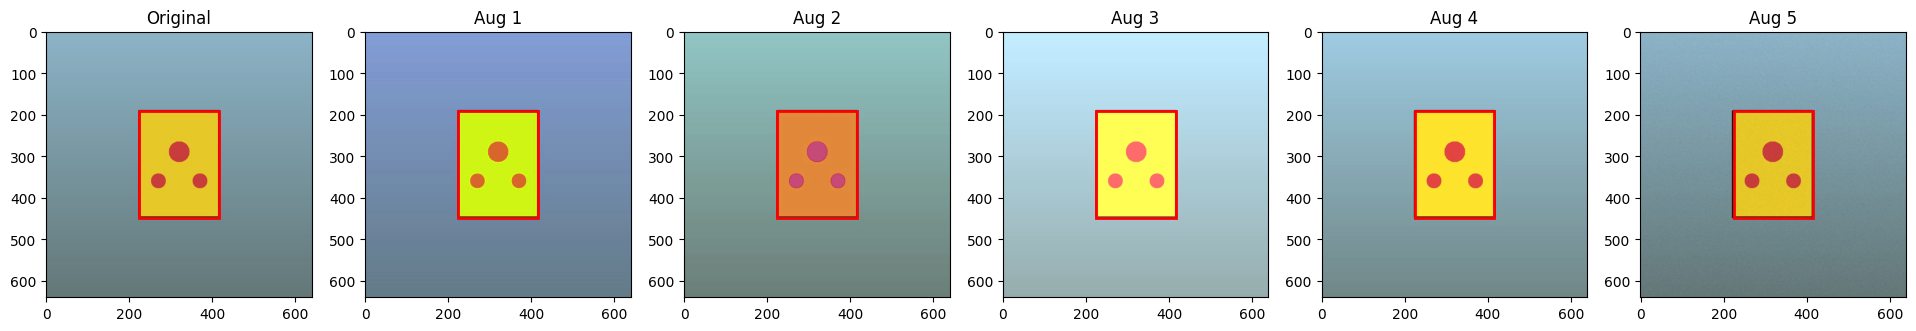

In [4]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])

fig, axes = plt.subplots(1, 6, figsize=(24, 4))

axes[0].imshow(image)
axes[0].set_title("Original")
H, W = image.shape[:2]
for xc, yc, w, h in bboxes:
    axes[0].add_patch(patches.Rectangle(
        ((xc - w / 2) * W, (yc - h / 2) * H), w * W, h * H, linewidth=2, edgecolor="red", facecolor="none"
    ))

for i in range(5):
    r = transform(image=image, bboxes=bboxes, class_labels=labels)
    img = r["image"].permute(1, 2, 0).numpy() * std + mean
    img = np.clip(img, 0, 1)
    axes[i + 1].imshow(img)
    axes[i + 1].set_title(f"Aug {i + 1}")
    H, W = img.shape[:2]
    for xc, yc, w, h in r["bboxes"]:
        axes[i + 1].add_patch(patches.Rectangle(
            ((xc - w / 2) * W, (yc - h / 2) * H), w * W, h * H,
            linewidth=2, edgecolor="red", facecolor="none"
        ))

plt.show()

In [8]:
import wandb
import torch

def train_with_wandb():
    config = {
        "lr": 0.001,
        "batch_size": 16,
        "epochs": 50,
        "model": "resnet18",
        "augmentation": "albumentations_v1"
    }

    wandb.init(
        project="cv-experiment",
        name="resnet18-aug-v1",
        config=config
    )

    for epoch in range(config["epochs"]):
        train_loss = 1.0 / (epoch + 1)
        val_loss = 1.2 / (epoch + 1)

        wandb.log({
            "epoch": epoch,
            "train/loss": train_loss,
            "val/loss": val_loss,
            "lr": config["lr"]
        })

    wandb.finish()

In [9]:
train_with_wandb()

wandb: ERROR The nbformat package was not found. It is required to save notebook history.


epoch,▁▁▁▁▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇███
lr,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train/loss,█▄▃▃▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val/loss,█▄▃▃▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch,49
lr,0.001
train/loss,0.02
val/loss,0.024
